Загрузка датасета

In [1]:
!gdown 1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql

Downloading...
From (original): https://drive.google.com/uc?id=1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql
From (redirected): https://drive.google.com/uc?id=1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql&confirm=t&uuid=36f9d188-cdd6-496d-a6e2-3e0f60006c57
To: /content/PH2Dataset.rar
100% 162M/162M [00:02<00:00, 66.0MB/s]


Скачали rar архив, распакуем его

In [2]:
get_ipython().system_raw("unrar x PH2Dataset.rar")

Стуктура датасета у нас следующая:

    IMD_002/
        IMD002_Dermoscopic_Image/
            IMD002.bmp
        IMD002_lesion/
            IMD002_lesion.bmp
        IMD002_roi/
            ...
    IMD_003/
        ...
        ...

 Здесь `X.bmp` — изображение, которое нужно сегментировать, `X_lesion.bmp` — результат сегментации.

Для загрузки датасета можно использовать skimage: [`skimage.io.imread()`](https://scikit-image.org/docs/dev/api/skimage.io.html)


In [3]:
images = []
lesions = []
from skimage.io import imread
root = 'PH2Dataset'
import os

for root, dirs, files in os.walk(os.path.join(root, 'PH2 Dataset images')):
  if root.endswith('_Dermoscopic_Image'):
    images.append(imread(os.path.join(root, files[0])))
  if root.endswith('_lesion'):
    lesions.append(imread(os.path.join(root, files[0])))

Изображения имеют разные размеры, приведём их к 256x256

функция resize() автоматически нормализиет изображения [0,1]

In [4]:
from skimage.transform import resize
size = (256, 256)
X = [resize(x, size, mode='constant', anti_aliasing=True) for x in images]
Y = [resize(y, size, mode='constant', anti_aliasing=False) > 0.5 for y in lesions]

In [5]:
import numpy as np
X = np.array(X, np.float32)
Y = np.array(Y, np.float32)
print(f'Loaded {len(X)} images')

Loaded 200 images


In [6]:
import matplotlib.pyplot as plt


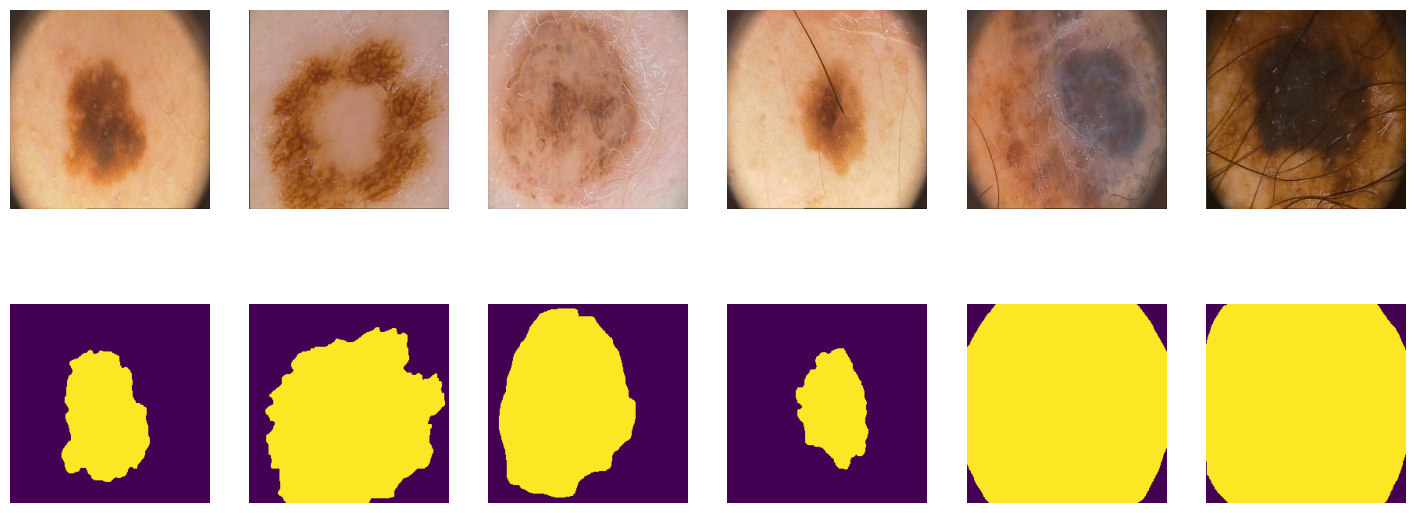

In [7]:
fig = plt.figure(figsize=(18,7))
for i in range(6):
  plt.subplot(2,6,i+1)
  plt.imshow(X[i])
  plt.axis("off")

  plt.subplot(2,6, i+7)
  plt.imshow(Y[i])
  plt.axis("off")
plt.show()

Разделим наш датасет длиной 200 на 100 train, 50 val и 50 test

In [8]:
ix = np.random.choice(len(X), len(X), False) #200 цифр в диапозоне [0:len(X)] и без повторений False
tr, val, ts = np.split(ix, [100, 150])

In [9]:
print(len(tr), len(val), len(ts))

100 50 50


## PyTorch

In [10]:
import torch

In [11]:
print(X.shape)
#у нас размер HWC
#а нам нужно CHW, поэтому меняет 3 и 1 размеры
print(np.rollaxis(X, 3, 1).shape)

(200, 256, 256, 3)
(200, 3, 256, 256)


In [12]:
train_dataloader = torch.utils.data.DataLoader(list(zip(np.rollaxis(X[tr], 3, 1), Y[tr, np.newaxis])), batch_size=25, shuffle=True)

valid_dataloader = torch.utils.data.DataLoader(list(zip(np.rollaxis(X[val], 3, 1), Y[val, np.newaxis])), batch_size=25, shuffle=False)

test_dataloader = torch.utils.data.DataLoader(list(zip(np.rollaxis(X[ts], 3, 1), Y[ts, np.newaxis])), batch_size=25, shuffle=False)

In [13]:
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [14]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 26.7 MB/s eta 0:00:00


In [15]:
from torchmetrics import JaccardIndex

iou_score = JaccardIndex(threshold = 0.5, task='binary', average='none').to(device)

## Функции лосса pytorch и самописные

In [16]:
import torch.nn.functional as F

In [17]:
bce_torch = torch.nn.BCELoss(reduction='sum') #общая сумма ошибок весто среднего
bce_torch_with_logits = torch.nn.BCEWithLogitsLoss(reduction='sum')

In [18]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [19]:
def bce_loss(y_pred, y_real):
  p = sigmoid(y_pred)
  term1 = y_real * np.log(p)
  term2 = (1 - y_real) * np.log(1-p)
  return -(term1+term2).sum()

def bce_true(y_pred, y_real):
  term1 = y_pred - y_real * y_pred
  term2 = np.log(1+np.exp(-y_pred))
  return (term1 + term2).sum()

Проверим корректность

In [20]:
y_pred = torch.randn(3, 2, requires_grad=False)
y_true = torch.rand(3, 2, requires_grad=False)

print(f'BCE loss from scratch bce_loss             = {bce_loss(y_pred, y_true)}')
print(f'BCE loss честно посчитанный                = {bce_true(y_pred, y_true)}')
print(f'BCE loss from torch bce_torch              = {bce_torch(torch.sigmoid(y_pred), y_true)}')
print(f'BCE loss from torch with logits bce_torch  = {bce_torch_with_logits(y_pred, y_true)}')

BCE loss from scratch bce_loss             = 5.148674011230469
BCE loss честно посчитанный                = 5.148674011230469
BCE loss from torch bce_torch              = 5.148674011230469
BCE loss from torch with logits bce_torch  = 5.148674011230469


/tmp/ipython-input-1253679003.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return 1 / (1 + np.exp(-x))
/tmp/ipython-input-993700903.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  term1 = y_real * np.log(p)
/tmp/ipython-input-993700903.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  term2 = (1 - y_real) * np.log(1-p)
/tmp/ipython-input-993700903.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  term2 = np.log(1+np.exp(-y_pred))


In [21]:
assert np.isclose(bce_loss(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true))
assert np.isclose(bce_loss(y_pred, y_true), bce_torch_with_logits(y_pred, y_true))
assert np.isclose(bce_true(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true))
assert np.isclose(bce_true(y_pred, y_true), bce_torch_with_logits(y_pred, y_true))

/tmp/ipython-input-1253679003.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return 1 / (1 + np.exp(-x))
/tmp/ipython-input-993700903.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  term1 = y_real * np.log(p)
/tmp/ipython-input-993700903.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  term2 = (1 - y_real) * np.log(1-p)
/tmp/ipython-input-993700903.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  term2 = np.log(1+np.exp(-y_pred))


In [22]:
y_pred = torch.randn((2, 1, 3, 3), requires_grad=False)
y_true = torch.randint(0, 2, (2, 1, 3, 3))

print(f'BCE loss from scratch bce_loss            = {bce_loss(y_pred, y_true)}')
print(f'BCE loss честно посчитанный               = {bce_true(y_pred, y_true)}')
print(f'BCE loss from torch bce_torch             = {bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float))}')
print(f'BCE loss from torch with logits bce_torch = {bce_torch_with_logits(y_pred, y_true.to(torch.float))}')

BCE loss from scratch bce_loss            = 11.592259407043457
BCE loss честно посчитанный               = 11.592259407043457
BCE loss from torch bce_torch             = 11.592259407043457
BCE loss from torch with logits bce_torch = 11.592259407043457


/tmp/ipython-input-1253679003.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return 1 / (1 + np.exp(-x))
/tmp/ipython-input-993700903.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  term1 = y_real * np.log(p)
/tmp/ipython-input-993700903.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  term2 = (1 - y_real) * np.log(1-p)
/tmp/ipython-input-993700903.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  term2 = np.log(1+np.exp(-y_pred))


In [23]:
assert np.isclose(bce_loss(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float)))
assert np.isclose(bce_loss(y_pred, y_true), bce_torch_with_logits(y_pred, y_true.to(torch.float)))
assert np.isclose(bce_true(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float)))
assert np.isclose(bce_true(y_pred, y_true), bce_torch_with_logits(y_pred, y_true.to(torch.float)))

/tmp/ipython-input-1253679003.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return 1 / (1 + np.exp(-x))
/tmp/ipython-input-993700903.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  term1 = y_real * np.log(p)
/tmp/ipython-input-993700903.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  term2 = (1 - y_real) * np.log(1-p)
/tmp/ipython-input-993700903.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  term2 = np.log(1+np.exp(-y_pred))


In [24]:
!gdown --folder 1EX0RW1TRQVkLmR1h6miCQqyhYPFyg28M

Retrieving folder contents
Processing file 1--WxvBdpMn_NOmYPf3a4au8MHzfx5baC labels.pt
Processing file 1-0A7_CS_vKiSCkgIDJ4joThCEcFedA3I logits.pt
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1--WxvBdpMn_NOmYPf3a4au8MHzfx5baC
To: /content/for_asserts/labels.pt
100% 1.18k/1.18k [00:00<00:00, 4.81MB/s]
Downloading...
From: https://drive.google.com/uc?id=1-0A7_CS_vKiSCkgIDJ4joThCEcFedA3I
To: /content/for_asserts/logits.pt
100% 1.18k/1.18k [00:00<00:00, 5.52MB/s]
Download completed


In [25]:
path_to_dummy_samples = '/content/for_asserts'
dummpy_sample = {'logits': torch.load(f'{path_to_dummy_samples}/logits.pt'),
                 'labels': torch.load(f'{path_to_dummy_samples}/labels.pt')}
dummpy_sample['labels'] = dummpy_sample['labels'].to(device)
dummpy_sample['logits'] = dummpy_sample['logits'].to(device)

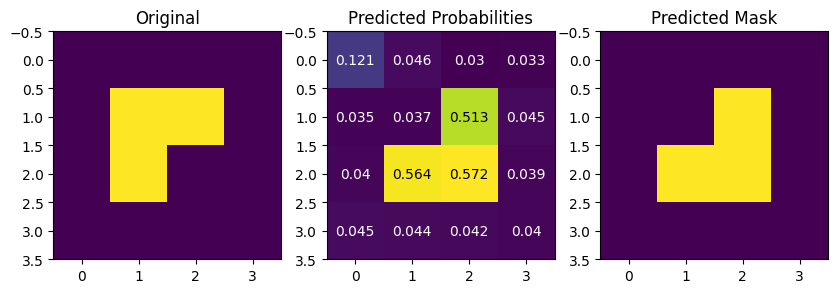

In [26]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize= (10,3*10))

ax1.imshow(dummpy_sample['labels'].squeeze(1)[0].cpu())
ax1.set_title("Original")

ax2.imshow(dummpy_sample['logits'].sigmoid().squeeze(1)[0].cpu())
for (j,i),label in np.ndenumerate(dummpy_sample['logits'].sigmoid().squeeze(1)[0].cpu()):
    if label < 0.5:
        color = 'white'
    else:
        color = 'black'
    ax2.text(i,j,round(label,3), color=color, ha='center',va='center')

ax2.set_title("Predicted Probabilities")

ax3.imshow((dummpy_sample['logits'].sigmoid() > 0.5).squeeze(1)[0].cpu())
ax3.set_title("Predicted Mask")
plt.show()

In [27]:
bce_loss_score = bce_loss(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu())
bce_true_score = bce_true(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu())
bce_torch_score = bce_torch(torch.sigmoid(dummpy_sample['logits'].cpu()), dummpy_sample['labels'].cpu().float())
bce_torch_with_logits_score = bce_torch_with_logits(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu().float())
assert np.isclose(bce_loss_score, bce_torch_score)
assert np.isclose(bce_loss_score, bce_torch_with_logits_score)
assert np.isclose(bce_true_score, bce_torch_score)
assert np.isclose(bce_true_score, bce_torch_with_logits_score)

/tmp/ipython-input-1253679003.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return 1 / (1 + np.exp(-x))
/tmp/ipython-input-993700903.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  term1 = y_real * np.log(p)
/tmp/ipython-input-993700903.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  term2 = (1 - y_real) * np.log(1-p)
/tmp/ipython-input-993700903.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  term2 = np.log(1+np.exp(-y_pred))


In [28]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
import torch.optim as optim
from time import time

from matplotlib import rcParams
rcParams['figure.figsize'] = (15,4)

In [29]:
model_vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:05<00:00, 95.3MB/s]


In [30]:
model_vgg

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

Используется структура: 5 encoders + 5 decoders

In [31]:
class EncoderBlock(nn.Module):
  def __init__(self, in_channels, out_channels, depth, kernel_size=3, padding=1):
    super(EncoderBlock, self).__init__()
    self.layers = torch.nn.ModuleList()

    self.layers.append(torch.nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=kernel_size, padding=padding))
    self.layers.append(torch.nn.BatchNorm2d(out_channels))
    self.layers.append(torch.nn.ReLU(inplace=True)) #inplace меняет тот же тензор прямо в памяти

    for i in range(depth-1):
      self.layers.append(torch.nn.Conv2d(in_channels=out_channels, out_channels=out_channels, kernel_size=kernel_size, padding=padding))
      self.layers.append(torch.nn.BatchNorm2d(out_channels))
      self.layers.append(torch.nn.ReLU(inplace=True))

    self.maxpooling = torch.nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True)

  def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        x, indices = self.maxpooling(x)
        return x, indices

In [32]:
class DecoderBlock(nn.Module):
  def __init__(self, in_channels, out_channels, depth, kernel_size=3, padding=1):
    super(DecoderBlock, self).__init__()
    self.layers = torch.nn.ModuleList()

    self.layers.append(torch.nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=kernel_size, padding=padding))
    self.layers.append(torch.nn.BatchNorm2d(out_channels))
    self.layers.append(torch.nn.ReLU(inplace=True)) #inplace меняет тот же тензор прямо в памяти

    for i in range(depth-1):
      self.layers.append(torch.nn.Conv2d(in_channels=out_channels, out_channels=out_channels, kernel_size=kernel_size, padding=padding))
      self.layers.append(torch.nn.BatchNorm2d(out_channels))
      self.layers.append(torch.nn.ReLU(inplace=True))

    self.unpool = torch.nn.MaxUnpool2d(kernel_size, stride=2)

  def forward(self, x, indices, output_size=None):
    x = self.unpool(x, indices, output_size=output_size)
    for layer in self.layers:
      x = layer(x)
    return x

In [33]:
class SegNet(nn.Module):
  def __init__(self, in_channels=3, out_channels=1, num_features=64):
    super(SegNet, self).__init__()
    # Encoder Block
    self.encoder0 = EncoderBlock(in_channels, num_features, depth=2)
    self.encoder1 = EncoderBlock(num_features, num_features * 2, depth=2)
    self.encoder2 = EncoderBlock(num_features * 2, num_features * 4, depth=3)
    self.encoder3 = EncoderBlock(num_features * 4, num_features * 8, depth=3)

    #bottleneck encoder
    self.encoder4 = EncoderBlock(num_features * 8 , num_features * 8, depth=3)

    #bottleneck decoder
    self.decoder0 = DecoderBlock(num_features * 8, num_features * 8, depth=3)

    # Decoder Block
    self.decoder1 = DecoderBlock(num_features * 8, num_features * 4, depth=3)
    self.decoder2 = DecoderBlock(num_features * 4, num_features * 2, depth=3)
    self.decoder3 = DecoderBlock(num_features * 2, num_features, depth=2)
    self.decoder4 = DecoderBlock(num_features, out_channels, depth=2)


  def forward(self, x):
    x, indices0 = self.encoder0(x)
    x, indices1 = self.encoder1(x)
    x, indices2 = self.encoder2(x)
    x, indices3 = self.encoder3(x)
    x, indices4 = self.encoder4(x)

    x = self.decoder0(x, indices4)
    x = self.decoder1(x, indices3)
    x = self.decoder2(x, indices2)
    x = self.decoder3(x, indices1)
    x = self.decoder4(x, indices0)

    return x

In [34]:
from tqdm.notebook import tqdm

In [35]:
def train_single_epoch(model, optimizer, criterion, train_dataloader):
    model.train()

    avg_loss = 0
    for X_batch, Y_batch in tqdm(train_dataloader):
        X_batch = X_batch.to(device)
        Y_batch = Y_batch.to(device)

        Y_pred = model(X_batch)
        loss = criterion(Y_pred, Y_batch) # forward-pass

        loss.backward()  # backward-pass
        optimizer.step()  # update weights
        optimizer.zero_grad() # set parameter gradients to zero

        # calculate loss to show the user
        avg_loss += loss

    avg_loss = avg_loss/len(train_dataloader)

    return model, avg_loss

In [36]:
def validate_single_epoch(model, criterion, valid_dataloader):

    iou_score = JaccardIndex(threshold = 0.5, task='binary', average='none').to(device)
    model.eval()

    avg_loss = 0
    avg_iou = 0
    with torch.no_grad():
      for X_batch, Y_batch in tqdm(valid_dataloader):
          X_batch = X_batch.to(device)
          Y_batch = Y_batch.to(device)

          Y_pred = model(X_batch)
          iou = iou_score(Y_pred, Y_batch)
          loss = criterion(Y_pred, Y_batch)
          avg_loss += loss
          avg_iou += iou

    avg_loss = avg_loss/len(valid_dataloader)
    avg_iou = avg_iou/len(valid_dataloader)

    return model, avg_loss, avg_iou

In [37]:
def train(model, optimizer, criterion, epochs, train_dataloader, valid_dataloader):

    total_train_loss = []
    total_val_loss = []
    total_val_iou = []

    best_val_loss = float('inf')
    best_val_iou = 0

    for epoch in tqdm(range(epochs)):

        model, train_loss = train_single_epoch(model, optimizer, criterion, train_dataloader)
        model, val_loss, val_iou = validate_single_epoch(model, criterion, valid_dataloader)
        print(f'Epoch {epoch}: train loss = {train_loss}')
        print(f'Epoch {epoch}: val loss = {val_loss}')
        print(f'Epoch {epoch}: val iou = {val_iou}')

        total_train_loss.append(train_loss.cpu().detach().numpy())
        total_val_loss.append(val_loss.cpu().detach().numpy())
        total_val_iou.append(val_iou.cpu().detach().numpy())

    statistics = {'train loss': total_train_loss,
                  'val_loss': total_val_loss,
                  'val_iou': total_val_iou}

    return model, statistics

In [38]:
model = SegNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()
epochs = 20

In [39]:
model, statistics = train(model, optimizer, criterion, epochs, train_dataloader, valid_dataloader)

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

RuntimeError: Expected shape of indices to be: [25, 512, 17, 17] but got: [25, 512, 16, 16]